In [176]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [221]:
df_customers = pd.read_csv("../data/olist_customers_dataset.csv")
df_geolocation = pd.read_csv("../data/olist_geolocation_dataset.csv")
df_order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
df_payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
df_reviews_dataset = pd.read_csv("../data/olist_order_reviews_dataset.csv")
df_orders = pd.read_csv("../data/olist_orders_dataset.csv")
df_products = pd.read_csv("../data/olist_products_dataset.csv")
df_sellers = pd.read_csv("../data/olist_sellers_dataset.csv")
df_product_category_name = pd.read_csv("../data/product_category_name_translation.csv")

In [224]:
df_sellers.head(5)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [179]:
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

In [180]:
df_orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                           str
order_delivered_carrier_date                str
order_delivered_customer_date               str
order_estimated_delivery_date               str
dtype: object

In [181]:
df_orders['data_formatada'] = df_orders['order_purchase_timestamp'].dt.date
df_orders['year'] = df_orders['order_purchase_timestamp'].dt.year
df_orders['ano_mes'] = df_orders['order_purchase_timestamp'].dt.to_period('M')

In [182]:
df_orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,data_formatada,year,ano_mes
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10-02,2017,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07-24,2018,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08-08,2018,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11-18,2017,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02-13,2018,2018-02


1) Quantidade de vendas por data

In [183]:

df_vendas_por_mes = (
    df_orders.groupby('ano_mes')['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'qtd_vendas'})
)

df_vendas_por_mes.sort_values(by='qtd_vendas', ascending=False).head(5)

,ano_mes,qtd_vendas
13,2017-11,7544
15,2018-01,7269
17,2018-03,7211
18,2018-04,6939
19,2018-05,6873


## Evolução de Vendas
Pico em **novembro/2017** com 7.544 pedidos, provavelmente pela Black Friday.

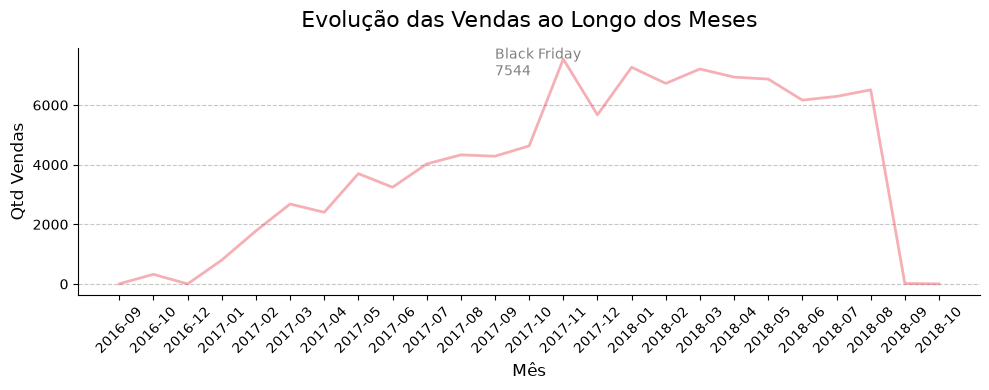

In [184]:
# fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(df_vendas_por_mes['ano_mes'].astype(str), df_vendas_por_mes['qtd_vendas'], lw=1.5, color='r')

# ax.set_title('Evolução das vendas ao longo dos meses', fontsize=18)
# plt.xticks(rotation=45)
# ax.set_xlabel('Ano mês', fontsize=12)
# ax.set_ylabel('Qtd Vendas', fontsize=12)
# plt.tight_layout()
# plt.show()
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df_vendas_por_mes['ano_mes'].astype(str), df_vendas_por_mes['qtd_vendas'], 
        lw=2, color='#E63946', markersize=4, alpha=0.4)

# Destaca o pico
idx_max = df_vendas_por_mes['qtd_vendas'].idxmax()
ax.annotate('Black Friday\n7544', 
            xy=(idx_max, 7544),
            xytext=(idx_max - 2, 7000),
            fontsize=10, color='gray')

# Estilo
ax.set_title('Evolução das Vendas ao Longo dos Meses', fontsize=16, pad=15)
ax.set_xlabel('Mês', fontsize=12)
ax.set_ylabel('Qtd Vendas', fontsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)  # grid só horizontal
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)  # remove bordas desnecessárias

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [188]:
df_products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Top 10 produtos

In [189]:
df_top_10_produtos = (df_order_items.groupby(by=['product_id'])['price'].sum()).sort_values(ascending=False).head(10).reset_index()
df_top_10_produtos

,product_id,price
0,bb50f2e236e5eea0100680137654686c,63885.00
1,6cdd53843498f92890544667809f1595,54730.20
2,d6160fb7873f184099d9bc95e30376af,48899.34
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51
4,99a4788cb24856965c36a24e339b6058,43025.56
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60
6,25c38557cf793876c5abdd5931f922db,38907.32
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90
8,53b36df67ebb7c41585e8d54d6772e08,37683.42
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90


TOP 10 categorias

In [205]:
top_10_categorias = (
    df_order_items.merge(df_products, on='product_id', how='left')
    [['product_id', 'product_category_name']]
    .groupby('product_category_name')['product_id']
    .count()
    .reset_index()
    .rename(columns={'product_id': 'qtd_vendida'})
    .sort_values(by='qtd_vendida', ascending=False)
    .head(10)
)
top_10_categorias


,product_category_name,qtd_vendida
13,cama_mesa_banho,11115
11,beleza_saude,9670
32,esporte_lazer,8641
54,moveis_decoracao,8334
44,informatica_acessorios,7827
72,utilidades_domesticas,6964
66,relogios_presentes,5991
70,telefonia,4545
40,ferramentas_jardim,4347
8,automotivo,4235


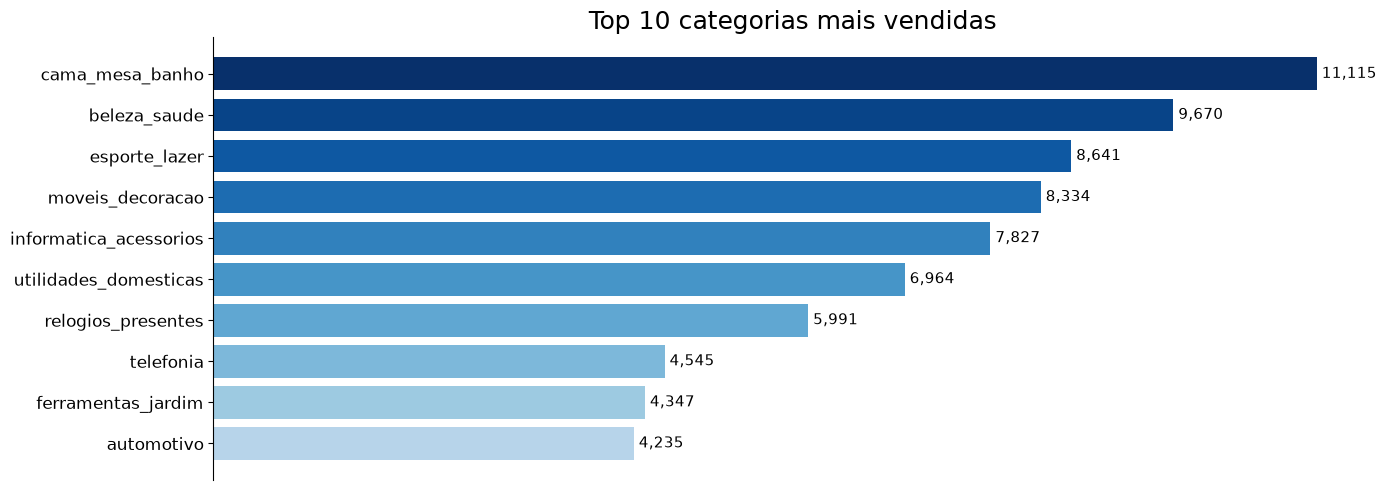

In [207]:
top_10_categorias_plot = top_10_categorias.sort_values(by='qtd_vendida', ascending=True)

fig, ax = plt.subplots(figsize=(14, 5))

# Gradiente azul
import matplotlib.cm as cm
n = len(top_10_categorias_plot)
cores = [cm.Blues(0.3 + 0.7 * i / (n - 1)) for i in range(n)]

bars = ax.barh(top_10_categorias_plot['product_category_name'], 
               top_10_categorias_plot['qtd_vendida'], color=cores)

# Valor na frente de cada barra
for bar, val in zip(bars, top_10_categorias_plot['qtd_vendida']):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=11)

# Remove eixo X e bordas
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Top 10 categorias mais vendidas', fontsize=18)
ax.xaxis.set_visible(False)  # remove eixo X
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.yaxis.set_tick_params(labelsize=12)
plt.tight_layout()
plt.show()

Qual o estado que mais compra?"Qual estado mais fatura em vendas?

In [ ]:
df_order_items.merge(
    df_sellers,
    on='seller_id',
    how='left'
).groupby(by='seller_state')['price'].sum().reset_index().sort_values(by='price', ascending=False).head(5)

,seller_state,price
22,SP,8753396.21
15,PR,1261887.21
8,MG,1011564.74
16,RJ,843984.22
20,SC,632426.07


In [235]:
df_orders.merge(
    df_customers, on='customer_id', how='left'
).merge(
    df_order_items, on='order_id', how='left'
).groupby('customer_state')['price'].sum().reset_index().sort_values(by='price', ascending=False).head(5)

,customer_state,price
25,SP,5202955.05
18,RJ,1824092.67
10,MG,1585308.03
22,RS,750304.02
17,PR,683083.76


In [236]:
df_customers.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [239]:
df_qtd_pedido_por_cliente = df_orders.merge(
    df_customers,
    on='customer_id',
    how='left'
).groupby('customer_state')['order_id'].count().reset_index().sort_values(by='order_id', ascending=False).head(5)

df_qtd_pedido_por_cliente.rename(columns={'order_id': 'qtd_pedidos'}, inplace=True)

df_qtd_pedido_por_cliente

,customer_state,qtd_pedidos
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
